# Instant Model Experiments (Gradient Boosting Classifier)

We load `instant_mock.csv`, pick the sensor features, and predict `comfortValue` classes.
We split into train/val/test and run a small grid search using a Gradient Boosting Classifier. 
Gradient Boosting builds trees sequentially, correcting the errors of previous trees.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [ ]:
import os
import pandas as pd

data_path = '../../data/processed/instant_mock.csv'

target_col = 'comfortValue'
group_col = 'room' 
feature_cols = ['humidity', 'light', 'temperature', 'noise', 'co2']

df = pd.read_csv(data_path)

columns_to_keep = feature_cols + [target_col, group_col]
df = df[columns_to_keep].dropna()

if pd.api.types.is_numeric_dtype(df[target_col]):
    df[target_col] = df[target_col].round().astype(int)

print(f"Rooms found: {df[group_col].unique()}")
print(f"Rows after cleaning: {len(df):,}")
display(df.head())

Rooms found: ['Lab 4.2' 'Room 2.5' 'Room 2.12' 'Lab 2.2']
Rows after cleaning: 1,812


,humidity,light,temperature,noise,co2,comfortValue,room
0,4225.0,7.669843,25.1,7.810250,0.001916,4,Lab 4.2
1,4225.0,7.669843,25.1,7.810250,0.001916,5,Lab 4.2
2,4096.0,6.835845,25.2,7.810250,0.001976,3,Lab 4.2
3,4096.0,6.835845,25.2,7.810250,0.001976,4,Lab 4.2
4,3969.0,7.039566,25.3,7.745967,0.001938,4,Lab 4.2


In [6]:
from sklearn.model_selection import GroupShuffleSplit

X = df[feature_cols]
y = df[target_col]
groups = df[group_col]

# 1. Split into Train (2 rooms) and Temp (2 rooms)
# test_size=0.5 on 4 groups means 2 groups go to train, 2 go to temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

# 2. Split Temp into Val (1 room) and Test (1 room)
# test_size=0.5 on 2 groups means 1 group goes to val, 1 goes to test
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(f"Train size: {len(X_train):,} (Rooms: {groups.iloc[train_idx].unique()})")
print(f"Val size:   {len(X_val):,} (Rooms: {groups_temp.iloc[val_idx].unique()})")
print(f"Test size:  {len(X_test):,} (Rooms: {groups_temp.iloc[test_idx].unique()})")

Train size: 1,285 (Rooms: ['Room 2.12' 'Lab 2.2'])
Val size:   286 (Rooms: ['Lab 4.2'])
Test size:  241 (Rooms: ['Room 2.5'])


In [7]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
}

gbc = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(
    gbc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

def eval_split(name, X_split, y_split):
    preds = best_model.predict(X_split)
    acc = accuracy_score(y_split, preds)
    print(f"{name} accuracy: {acc:.3f}")

eval_split("Validation", X_val, y_val)
eval_split("Test", X_test, y_test)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best CV accuracy: 0.340
Validation accuracy: 0.444
Test accuracy: 0.477


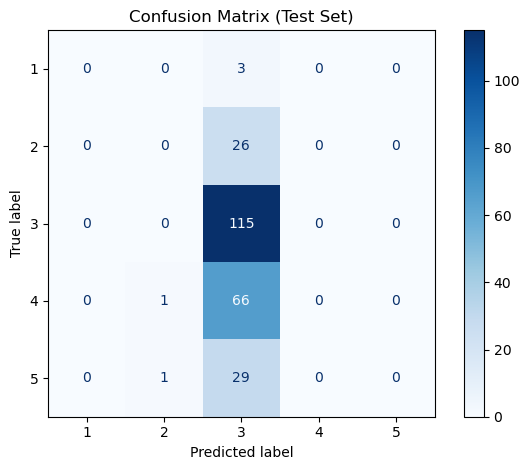

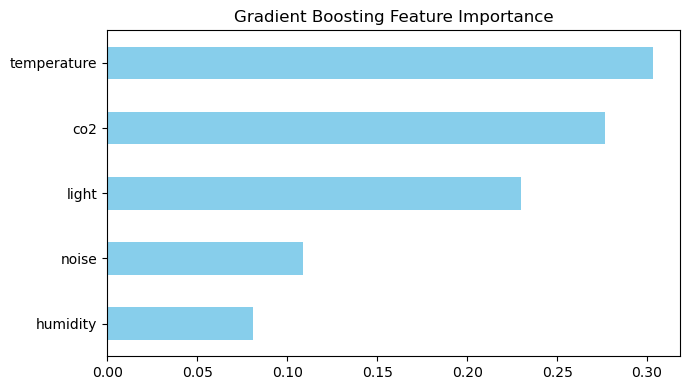

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_preds = best_model.predict(X_test)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    cmap='Blues',
    colorbar=True,
)
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='skyblue')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

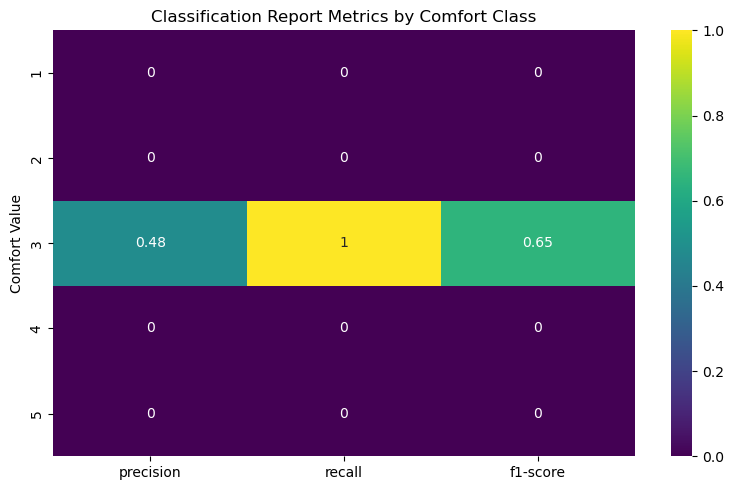

In [9]:
import seaborn as sns
from sklearn.metrics import classification_report

# 3. Classification Report Heatmap
# Get the report as a dictionary so we can plot it
report = classification_report(y_test, test_preds, output_dict=True, zero_division=0)

# Remove the 'accuracy' score and overall averages to keep the heatmap clean for just the classes
if 'accuracy' in report:
    del report['accuracy']
if 'macro avg' in report:
    del report['macro avg']
if 'weighted avg' in report:
    del report['weighted avg']

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Plot
plt.figure(figsize=(8, 5))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', vmin=0, vmax=1)
plt.title('Classification Report Metrics by Comfort Class')
plt.ylabel('Comfort Value')
plt.tight_layout()
plt.show()

## Notes

Gradient Boosting is a good small-tabular-data candidate because it can learn non-linear thresholds and feature interactions without requiring many rows.
Compare this notebook mainly against Random Forest using validation macro F1 and test bad-class recall.
